<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 10: Cryogenic Systems</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part III: Systems Integration | SCE Futures</p>
</div>

## Table of Contents

1. [Why 4 Kelvin?](#why-4k)
2. [Liquid Helium Basics](#lhe-basics)
3. [Cryostat Types](#cryostat-types)
4. [Helium Management & Recovery](#helium-management)
5. [Cooling Power Budgets](#cooling-budgets)
6. [Cryogenic Safety](#cryo-safety)
7. [Lab Setup & Operations](#lab-setup)
   - 7.1 [Electrical Ground Isolation](#electrical-isolation)
8. [Summary](#summary)

<a id="learning-objectives"></a>
!!! abstract "Learning Objectives"
    - Distinguish the 4.2 K measurement regime from the 5 K production-model operating point.
    - Compare wet cryostats, closed-cycle refrigerators, and dilution refrigerators by use case.
    - Construct a staged heat budget from radiation, conduction, wiring, and active loads.
    - Apply cryogen, pressure, oxygen-deficiency, electrical, and mechanical safety controls.

In [1]:
# Setup
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'purple': '#9C27B0',
    'cyan': '#00BCD4',
    'cold': '#00BCD4',
    'warm': '#FF5722',
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


---

<a id='why-4k'></a>
## 1. Why 4 Kelvin?

Superconducting electronics require temperatures below the critical temperature (Tc) of the superconducting materials used.

### Critical Temperatures of Common Materials

| Material | Tc (K) | Typical Operating Temp | Notes |
|----------|--------|------------------------|-------|
| Niobium (Nb) | 9.2 | 4.2 K | Workhorse material, excellent properties |
| NbN | 16 | 4-10 K | Higher Tc, used in some detectors |
| NbTiN | 14-15 | 4-10 K | Good for kinetic inductance devices |
| Al | 1.2 | 0.1 K (mK) | Used in qubits, requires dilution fridge |
| YBCO | 93 | 77 K | High-Tc, but hard to make JJs |

### Why Not Just Below Tc?

Operating well below Tc provides:

1. **Larger energy gap**: Reduces thermal noise and quasiparticle generation
2. **Margin for heating**: Chip dissipation raises local temperature
3. **Reproducibility**: Properties are more stable far from the transition
4. **Convenience**: 4.2 K is the boiling point of liquid helium at 1 atm

### Bench and production operating points

A 4.2 K liquid-helium bath is a natural measurement point. Bench measurements and first small systems commonly remain near 4 K, while the current production energy model uses 5 K because refrigerator performance improves steeply with stage temperature:

- **4.2 K bench basis**: an atmospheric LHe bath remains near its boiling point while liquid is present
- **5 K production-model basis**: larger-system efficiency calculations use 5 K and a 5–6 K working band
- **Measurement labels remain fixed**: the 1.4 zJ/JJ-cycle reference and 0.040 zJ Landauer value are both 4.2 K quantities
- **Large installed base**: Decades of cryogenic infrastructure
- **Reasonable cooling power**: 1-2 W available from GM/PT cryocoolers
- **Compatible with Nb**: Well below Tc = 9.2 K

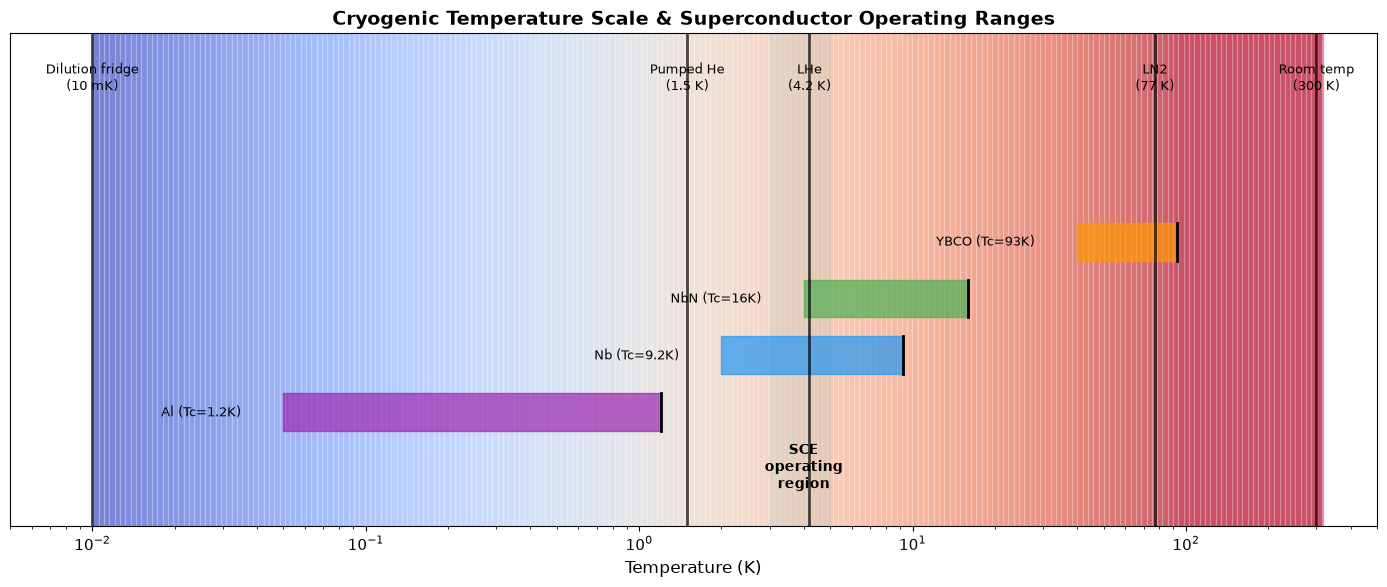

In [2]:
# Visualize: Temperature scale and superconductor operating regions
fig, ax = plt.subplots(figsize=(14, 6))

# Temperature scale (log)
temps = np.logspace(-2, 2.5, 1000)

# Draw temperature bar
for i, t in enumerate(temps[:-1]):
    color = plt.cm.coolwarm(np.log10(t) / 4 + 0.5)
    ax.axvspan(t, temps[i+1], alpha=0.3, color=color)

# Mark key temperatures
markers = {
    'Dilution fridge\n(10 mK)': 0.01,
    'Pumped He\n(1.5 K)': 1.5,
    'LHe\n(4.2 K)': 4.2,
    'LN2\n(77 K)': 77,
    'Room temp\n(300 K)': 300,
}

for label, temp in markers.items():
    ax.axvline(temp, color='black', linewidth=2, alpha=0.7)
    ax.text(temp, 1.15, label, ha='center', fontsize=9, rotation=0)

# Material Tc ranges
materials = [
    ('Al (Tc=1.2K)', 0.05, 1.2, COLORS['purple']),
    ('Nb (Tc=9.2K)', 2, 9.2, COLORS['primary']),
    ('NbN (Tc=16K)', 4, 16, COLORS['success']),
    ('YBCO (Tc=93K)', 40, 93, COLORS['secondary']),
]

for i, (name, t_op, tc, color) in enumerate(materials):
    y = 0.3 + i * 0.15
    ax.fill_betweenx([y-0.05, y+0.05], t_op, tc, color=color, alpha=0.7)
    ax.plot([tc, tc], [y-0.05, y+0.05], 'k-', linewidth=2)
    ax.text(t_op * 0.7, y, name, ha='right', va='center', fontsize=9)

ax.set_xscale('log')
ax.set_xlim(0.005, 500)
ax.set_ylim(0, 1.3)
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_yticks([])
ax.set_title('Cryogenic Temperature Scale & Superconductor Operating Ranges', fontsize=14, fontweight='bold')

# Highlight SCE operating region
ax.axvspan(3, 5, alpha=0.2, color=COLORS['cold'], zorder=0)
ax.text(4, 0.1, 'SCE\noperating\nregion', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<a id='lhe-basics'></a>
## 2. Liquid Helium Basics

### Properties of Liquid Helium

| Property | Value | Implication |
|----------|-------|-------------|
| Boiling point (1 atm) | 4.2 K | Natural operating temperature |
| Latent heat | 2.6 kJ/L | Low cooling capacity per liter |
| Density | 125 kg/m³ | Light, easy to transfer |
| Cost | $15-30/L (2024) | Significant operating expense |
| Viscosity | Very low | Leaks through tiny gaps |
| Expansion ratio | 1:750 | 1L liquid → 750L gas |

### Comparison: LHe vs LN2

| Property | LHe | LN2 |
|----------|-----|-----|
| Boiling point | 4.2 K | 77 K |
| Latent heat | 2.6 kJ/L | 161 kJ/L |
| Cost | $15-30/L | $0.50-2/L |
| Availability | Limited | Abundant |

LN2 has 60× more cooling capacity per liter! This is why LN2 shields are used to reduce LHe consumption.

### Helium Supply Chain

Helium is extracted from natural gas and is a **non-renewable resource**:

1. **Sources**: US (Federal Helium Reserve depleting), Qatar, Algeria, Russia, Australia
2. **Supply volatility**: Prices have spiked 3-5× during shortages (2012-2013, 2019)
3. **Grade matters**: Research grade (99.999%) costs more than industrial
4. **Recovery is essential**: Modern labs must recover and reliquefy

### Dewar Types

| Type | Capacity | Hold Time | Use Case |
|------|----------|-----------|----------|
| Transport dewar | 30-60 L | 1-3 days | Moving LHe between buildings |
| Storage dewar | 100-500 L | 1-2 weeks | Lab storage |
| Research dewar | 50-100 L | Varies | Dip probe experiments |

<a id='cryostat-types'></a>
## 3. Cryostat Types

### Wet Cryostats (LHe Bath)

**How it works**: Sample immersed directly in liquid helium bath

**Advantages**:
- Simple, reliable temperature control
- High cooling power (limited by boil-off rate)
- Self-regulating at 4.2 K
- Fast cooldown (minutes to hours)

**Disadvantages**:
- Ongoing LHe consumption ($$$)
- Requires helium infrastructure
- Regular refills needed
- Vibration from boiling

**Best for**: R&D, university labs, quick experiments, high-power devices

---

### Dry Cryostats (Cryocooler-Based)

**How it works**: Closed-cycle refrigerator cools sample through thermal link

**Types of cryocoolers**:

| Type | Base Temp | Power at 4K | Vibration | Cost |
|------|-----------|-------------|-----------|------|
| Gifford-McMahon (GM) | 2.5-4 K | 1-2 W | Moderate | $50-100K |
| Pulse Tube (PT) | 2.5-4 K | 0.5-1.5 W | Low | $80-150K |
| Stirling | 20-80 K | 5-50 W | High | $20-50K |

**Advantages**:
- No LHe consumption (just electricity + maintenance)
- Unattended operation for weeks/months
- Better for production/deployment
- Predictable operating costs

**Disadvantages**:
- Limited cooling power (~1-2 W at 4K)
- Longer cooldown (12-24 hours typical)
- Mechanical vibration (especially GM)
- Higher upfront cost
- Compressor maintenance (every 10-20k hours)

**Best for**: Production testing, deployed systems, long-running experiments

---

### Dilution Refrigerators

For temperatures below 1K (needed for qubits, not typical SCE):

- Uses ³He/⁴He mixture
- Base temperature: 10-50 mK
- Cost: $500K-1M+
- Mostly for quantum computing applications

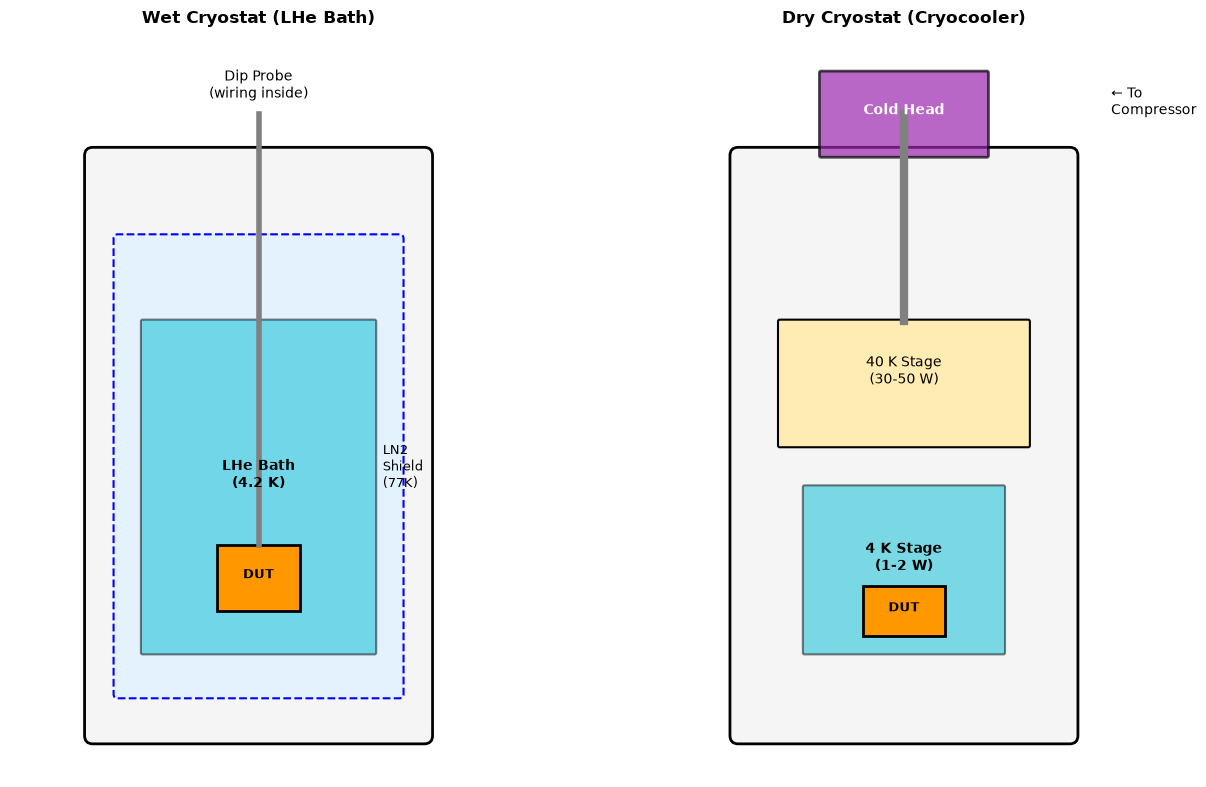

Wet systems: Simple, high cooling power, but consume LHe
Dry systems: No LHe, but limited cooling power (~1-2W at 4K)


In [3]:
# Visualize: Comparison of wet vs dry cryostat architectures
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left: Wet cryostat (LHe dewar with dip probe)
ax = axes[0]

# Outer vacuum jacket
outer = patches.FancyBboxPatch((1, 0.5), 4, 7, boxstyle="round,pad=0.1",
                                facecolor=COLORS['light'], edgecolor='black', linewidth=2)
ax.add_patch(outer)

# LN2 shield
ln2 = patches.FancyBboxPatch((1.3, 1), 3.4, 5.5, boxstyle="round,pad=0.05",
                              facecolor='#E3F2FD', edgecolor='blue', linewidth=1.5, linestyle='--')
ax.add_patch(ln2)
ax.text(4.5, 3.5, 'LN2\nShield\n(77K)', fontsize=9, ha='left')

# LHe bath
lhe = patches.FancyBboxPatch((1.6, 1.5), 2.8, 4, boxstyle="round,pad=0.02",
                              facecolor=COLORS['cold'], alpha=0.5, edgecolor='black', linewidth=1.5)
ax.add_patch(lhe)
ax.text(3, 3.5, 'LHe Bath\n(4.2 K)', fontsize=10, ha='center', fontweight='bold')

# Sample
sample = patches.Rectangle((2.5, 2), 1, 0.8, facecolor=COLORS['secondary'], edgecolor='black', linewidth=2)
ax.add_patch(sample)
ax.text(3, 2.4, 'DUT', fontsize=9, ha='center', fontweight='bold')

# Dip probe
ax.plot([3, 3], [2.8, 8], color='gray', linewidth=4)
ax.text(3, 8.2, 'Dip Probe\n(wiring inside)', fontsize=10, ha='center')

ax.set_xlim(0, 6)
ax.set_ylim(0, 9)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Wet Cryostat (LHe Bath)', fontsize=12, fontweight='bold')

# Right: Dry cryostat (cryocooler)
ax = axes[1]

# Vacuum chamber
chamber = patches.FancyBboxPatch((1, 0.5), 4, 7, boxstyle="round,pad=0.1",
                                  facecolor=COLORS['light'], edgecolor='black', linewidth=2)
ax.add_patch(chamber)

# 40K stage
stage40k = patches.FancyBboxPatch((1.5, 4), 3, 1.5, boxstyle="round,pad=0.02",
                                   facecolor='#FFECB3', edgecolor='black', linewidth=1.5)
ax.add_patch(stage40k)
ax.text(3, 4.75, '40 K Stage\n(30-50 W)', fontsize=10, ha='center')

# 4K stage
stage4k = patches.FancyBboxPatch((1.8, 1.5), 2.4, 2, boxstyle="round,pad=0.02",
                                  facecolor=COLORS['cold'], alpha=0.5, edgecolor='black', linewidth=1.5)
ax.add_patch(stage4k)
ax.text(3, 2.5, '4 K Stage\n(1-2 W)', fontsize=10, ha='center', fontweight='bold')

# Sample
sample2 = patches.Rectangle((2.5, 1.7), 1, 0.6, facecolor=COLORS['secondary'], edgecolor='black', linewidth=2)
ax.add_patch(sample2)
ax.text(3, 2, 'DUT', fontsize=9, ha='center', fontweight='bold')

# Cryocooler cold head
ax.plot([3, 3], [5.5, 8], color='gray', linewidth=6)
coldhead = patches.FancyBboxPatch((2, 7.5), 2, 1, boxstyle="round,pad=0.02",
                                   facecolor=COLORS['purple'], alpha=0.7, edgecolor='black', linewidth=2)
ax.add_patch(coldhead)
ax.text(3, 8, 'Cold Head', fontsize=10, ha='center', color='white', fontweight='bold')

# Compressor (external)
ax.text(5.5, 8, '\u2190 To\nCompressor', fontsize=10, ha='left')

ax.set_xlim(0, 6)
ax.set_ylim(0, 9)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Dry Cryostat (Cryocooler)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Wet systems: Simple, high cooling power, but consume LHe")
print("Dry systems: No LHe, but limited cooling power (~1-2W at 4K)")

<a id='helium-management'></a>
## 4. Helium Management & Recovery

### Why Recovery Matters

At $20-30/L and typical consumption of 50-200 L/week in an active lab:
- **Without recovery**: $50K-300K/year in helium alone
- **With recovery**: $5K-30K/year (90%+ recovery rate)

Recovery pays for itself within 1-2 years.

### Recovery System Components

```
Dewars/Cryostats → Collection bags → Recovery compressor →
Purifier → High-pressure storage → Liquefier → LHe storage
```

1. **Collection bags/bladders**: Capture boil-off gas from dewars and cryostats
2. **Recovery compressor**: Compress gas into high-pressure cylinders (200-300 bar)
3. **Purifier**: Remove air and moisture contamination
4. **Liquefier**: Convert gas back to LHe (optional, expensive)
5. **Storage**: High-pressure gas cylinders or liquid dewars

### Recovery Architectures

| Approach | Upfront Cost | Operating Cost | Best For |
|----------|--------------|----------------|----------|
| Bag + external liquefier | $10-50K | Pay per liter | Small labs |
| On-site liquefier | $500K-1M | Electricity only | Large labs |
| Closed-cycle (dry) | $100-300K | Maintenance | Production |

### Contamination

Helium gas can become contaminated with:
- **Air**: From leaks in collection system (>1 ppm causes problems)
- **Water vapor**: Condenses and freezes, blocking lines
- **Pump oil**: From older recovery compressors

Most liquefiers require <1 ppm impurities; contaminated gas must be purified or discarded.

<a id='cooling-budgets'></a>
## 5. Cooling Power Budgets

Designing a cryogenic system requires careful thermal budgeting.

### Heat Load Sources

| Source | Typical Value | Notes |
|--------|---------------|-------|
| Radiation (300K→4K) | 50 mW/m² | With MLI shielding |
| Conduction (wiring) | 1-10 mW/wire | Depends on material, length |
| Conduction (supports) | 10-100 mW | Inter-stage; typically included in cryocooler specs |
| Chip dissipation | 1-100 mW | Depends on circuit type |
| Amplifiers (HEMT) | 5-15 mW each | If used; major heat source |
| Amplifier bias power | ~10 mW typical | ~50 µA × 50 Ω × number of amplifiers |

### Heat Intercept Strategy

Use intermediate temperature stages to intercept heat before it reaches 4K:

```
300 K (room temp)
   │
   ├── Radiation shields (MLI)
   │
40-50 K (first stage)  ← Intercept most conduction heat here
   │                      30-50 W available
   ├── Thermal anchoring of wires
   │
4 K (second stage)     ← Only residual heat reaches here
                          1-2 W available
```

### Wire Heat Load Calculation

Heat conducted along a wire:

$$Q = \frac{A}{L} \int_{T_{cold}}^{T_{hot}} k(T) \, dT$$

Use the **thermal conductivity integral** for common materials:

| Material | ∫k dT (300→4K) | ∫k dT (40→4K) | Use |
|----------|----------------|---------------|-----|
| Copper (OFHC) | 15,000 W/m | 800 W/m | Short runs, 4K only |
| Phosphor bronze | 1,500 W/m | 80 W/m | General wiring |
| Stainless steel | 300 W/m | 15 W/m | Structural supports |
| Manganin | 400 W/m | 20 W/m | DC wiring |
| NbTi (SC below 9K) | 150 W/m | ~0 W/m | Best for 4K stage |

In [4]:
# Calculate: Example thermal budget for a cryocooler system

def wire_heat_load(n_wires, awg, length_m, material='phosphor_bronze', T_hot=40, T_cold=4):
    """
    Calculate heat load from wires.
    Using simplified thermal conductivity integrals.
    """
    # Wire diameters (mm) for common AWG
    awg_diameters = {36: 0.127, 32: 0.202, 28: 0.321, 24: 0.511}
    
    # Thermal conductivity integrals (W/m) from T_hot to 4K
    k_integrals = {
        'copper': {'300_4': 15000, '40_4': 800},
        'phosphor_bronze': {'300_4': 1500, '40_4': 80},
        'manganin': {'300_4': 400, '40_4': 20},
        'stainless': {'300_4': 300, '40_4': 15},
    }
    
    d = awg_diameters[awg] / 1000  # Convert to meters
    A = np.pi * (d/2)**2  # Cross-sectional area
    
    key = f'{T_hot}_4' if T_hot == 40 else '300_4'
    k_int = k_integrals[material][key]
    
    Q_per_wire = (A / length_m) * k_int
    return n_wires * Q_per_wire * 1000  # Convert to mW

print("="*70)
print("THERMAL BUDGET EXAMPLE: Cryocooler System for SCE Testing")
print("="*70)
print("\nSystem: Sumitomo RDK-415D (1.5W at 4.2K, 40W at 45K)")
print("-" * 50)

# 4K stage heat loads
loads_4k = {
    'Chip dissipation (AQFP)': 20,
    'DC wiring (20x 36AWG PhBr, 0.3m)': wire_heat_load(20, 36, 0.3, 'phosphor_bronze', 40, 4),
    'RF coax (4x SS, thermalized)': 4 * 5,
    'Mechanical supports (G10)': 30,
    'Radiation (with shield)': 10,
    'HEMT amplifier (1x)': 12,
}

print("\n4K Stage Heat Loads:")
total_4k = 0
for source, load in loads_4k.items():
    print(f"  {source}: {load:.1f} mW")
    total_4k += load

print(f"  {'─'*45}")
print(f"  TOTAL: {total_4k:.1f} mW")
print(f"  Available: 1500 mW")
print(f"  Margin: {(1500-total_4k)/1500*100:.0f}%")

# 40K stage heat loads
loads_40k = {
    'DC wiring (20x 36AWG PhBr from 300K)': wire_heat_load(20, 36, 0.5, 'phosphor_bronze', 300, 40) / 10,
    'RF coax (4x SS from 300K)': 4 * 200,
    'Radiation shield': 500,
    'Mechanical supports': 2000,
}

print("\n40K Stage Heat Loads:")
total_40k = 0
for source, load in loads_40k.items():
    print(f"  {source}: {load:.1f} mW")
    total_40k += load

print(f"  {'─'*45}")
print(f"  TOTAL: {total_40k:.1f} mW = {total_40k/1000:.1f} W")
print(f"  Available: 40 W")
print(f"  Margin: {(40000-total_40k)/40000*100:.0f}%")

THERMAL BUDGET EXAMPLE: Cryocooler System for SCE Testing

System: Sumitomo RDK-415D (1.5W at 4.2K, 40W at 45K)
--------------------------------------------------

4K Stage Heat Loads:
  Chip dissipation (AQFP): 20.0 mW
  DC wiring (20x 36AWG PhBr, 0.3m): 0.1 mW
  RF coax (4x SS, thermalized): 20.0 mW
  Mechanical supports (G10): 30.0 mW
  Radiation (with shield): 10.0 mW
  HEMT amplifier (1x): 12.0 mW
  ─────────────────────────────────────────────
  TOTAL: 92.1 mW
  Available: 1500 mW
  Margin: 94%

40K Stage Heat Loads:
  DC wiring (20x 36AWG PhBr from 300K): 0.1 mW
  RF coax (4x SS from 300K): 800.0 mW
  Radiation shield: 500.0 mW
  Mechanical supports: 2000.0 mW
  ─────────────────────────────────────────────
  TOTAL: 3300.1 mW = 3.3 W
  Available: 40 W
  Margin: 92%


---

<a id='cryo-safety'></a>
## 6. Cryogenic Safety

### Primary Hazards

| Hazard | Risk | Mitigation |
|--------|------|------------|
| **Asphyxiation** | He/N2 displace O2 | Ventilation, O2 monitors |
| **Cold burns** | Contact with cold surfaces/liquids | PPE, training |
| **Pressure** | Cryogen boil-off in sealed space | Pressure relief, no sealed containers |
| **Embrittlement** | Materials fail at cryo temps | Use appropriate materials |

### Wet Systems (LHe/LN2) | Additional Hazards

These hazards apply when handling liquid cryogens:

**Oxygen Deficiency**, 1 liter of liquid helium → 750 liters of gas!

| O2 Level | Effect |
|----------|--------|
| 21% | Normal atmosphere |
| 19.5% | OSHA minimum safe level |
| 16% | Impaired judgment, rapid breathing |
| 10% | Loss of consciousness |
| 6% | Death within minutes |

**Requirements for wet systems**:
- O2 monitors in all rooms with cryogens (audible alarms at 19.5%)
- Adequate ventilation (basement labs especially at risk!)
- Never enter a space after large release without O2 testing
- Battery backup for O2 monitors

**Pressure Safety** (wet systems):
- **Never seal a container with cryogens**: It will build pressure and explode
- **Pressure relief valves**: Required on all dewars, check regularly
- **Burst disks**: Backup protection
- **Ice plugs**: Can block vent lines; use warming heaters on vents
- **Transfer lines**: Always have a path for gas to escape

### Dry Systems (Cryocoolers) | Safety Considerations

Closed-cycle systems have fewer hazards but still require attention:

- **No asphyxiation risk** during normal operation (helium is sealed)
- **Cold surfaces**: 4K and 40K stages still cause cold burns if touched
- **Vacuum window failure**: Rare but can cause rapid pressure release
- **Compressor**: High-pressure helium lines; follow manufacturer guidelines
- **Electrical**: Compressors draw significant power; proper grounding required

### PPE Requirements

| Item | Wet Systems | Dry Systems |
|------|-------------|-------------|
| Face shield | Required for transfers | Not typically needed |
| Cryogenic gloves | Required for LHe/LN2 handling | Only for cold hardware |
| Long pants/sleeves | Always | Always |
| Closed-toe shoes | Always | Always |
| Safety glasses | Always | Always |

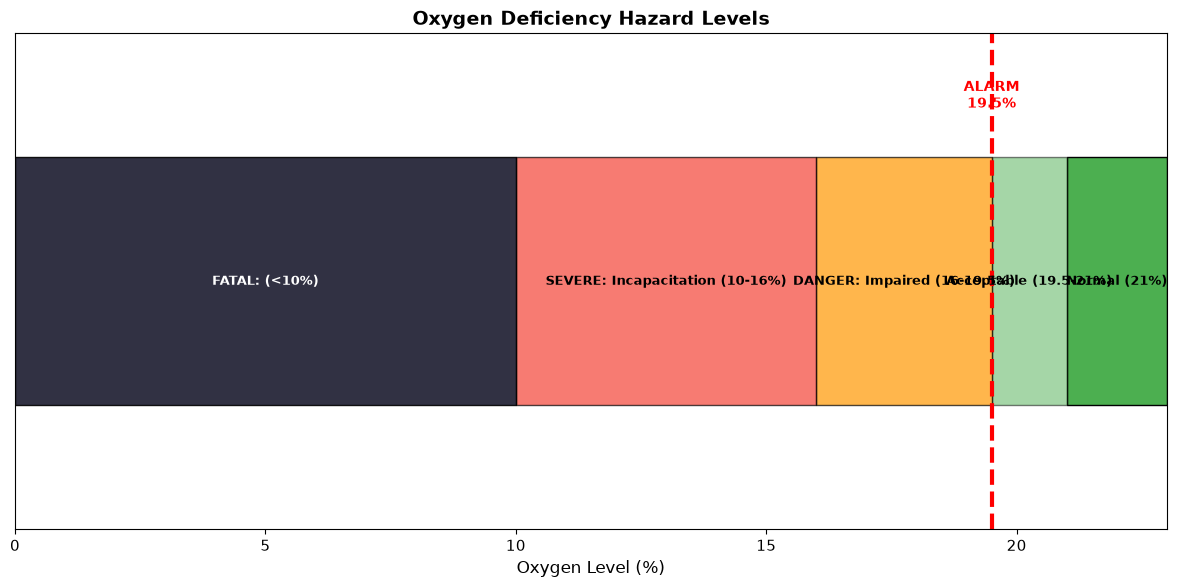


Key safety rules:
1. Follow the facility hazard assessment; use oxygen monitors with alarms wherever oxygen-deficiency risk requires them
2. Never work alone with large cryogen quantities
3. Know your escape routes
4. If alarm sounds, LEAVE IMMEDIATELY


In [5]:
# Visualize: Oxygen deficiency hazard zones
fig, ax = plt.subplots(figsize=(12, 6))

# O2 levels and colors
zones = [
    (21, 23, 'Normal (21%)', COLORS['success'], 1.0),
    (19.5, 21, 'Acceptable (19.5-21%)', COLORS['success'], 0.5),
    (16, 19.5, 'DANGER: Impaired (16-19.5%)', COLORS['secondary'], 0.7),
    (10, 16, 'SEVERE: Incapacitation (10-16%)', COLORS['danger'], 0.7),
    (0, 10, 'FATAL: (<10%)', COLORS['dark'], 0.9),
]

for o2_min, o2_max, label, color, alpha in zones:
    ax.barh(0, o2_max - o2_min, left=o2_min, height=0.5, 
            color=color, alpha=alpha, edgecolor='black')
    ax.text((o2_min + o2_max)/2, 0, label, ha='center', va='center', 
            fontsize=9, fontweight='bold', color='white' if color == COLORS['dark'] else 'black')

# Alarm threshold
ax.axvline(19.5, color='red', linewidth=3, linestyle='--')
ax.text(19.5, 0.35, 'ALARM\n19.5%', ha='center', fontsize=10, color='red', fontweight='bold')

ax.set_xlim(0, 23)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Oxygen Level (%)', fontsize=12)
ax.set_yticks([])
ax.set_title('Oxygen Deficiency Hazard Levels', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey safety rules:")
print("1. Follow the facility hazard assessment; use oxygen monitors with alarms wherever oxygen-deficiency risk requires them")
print("2. Never work alone with large cryogen quantities")
print("3. Know your escape routes")
print("4. If alarm sounds, LEAVE IMMEDIATELY")

<a id='lab-setup'></a>
## 7. Lab Setup & Operations

### Essential Lab Infrastructure

| Item | Wet Systems | Dry Systems |
|------|-------------|-------------|
| O2 monitors | Required (battery backup) | Optional (no open cryogens) |
| Ventilation | Critical | Standard lab ventilation |
| Dewar storage | Required, away from exits | Not needed |
| Helium recovery | Essential for cost | Not applicable |
| Compressed gas | For recovery system | For cryocooler charge |
| Electrical | Standard | Clean power for compressor |

---

### Dry System (Cryocooler) Operations

**Pre-Cooldown Checklist:**
- [ ] Vacuum system leak-checked (<10⁻⁵ mbar)
- [ ] All wiring connections verified at room temp
- [ ] Sample mounted with good thermal contact (use Apiezon grease)
- [ ] Thermal links verified
- [ ] Compressor helium charge checked

**Cooldown Procedure:**
1. Verify vacuum (<10⁻⁵ mbar)
2. Start compressor, verify helium flow
3. Monitor temperatures (40K stage: ~2 hrs, 4K stage: 6-12 hrs)
4. Verify all temperature sensors reading correctly
5. Begin device testing only after thermal equilibrium

**Common Failure Modes:**

| Symptom | Likely Cause | Debug |
|---------|--------------|-------|
| Won't cool below 40K | Vacuum leak | Check pressure, leak check |
| 4K stage too warm | Heat load too high | Check wiring, reduce cables |
| Temperature unstable | Poor thermal contact | Check mounting, add grease |
| Slow cooldown | Low helium charge | Check compressor pressure |
| Compressor cycling | Contaminated helium | May need purge/recharge |

---

### Wet System (LHe) Operations

**Pre-Cooldown Checklist:**
- [ ] Vacuum system leak-checked (<10⁻⁵ mbar)
- [ ] All wiring connections verified at room temp
- [ ] Sample mounted securely
- [ ] O2 monitors active and calibrated
- [ ] Recovery bags/system ready
- [ ] LHe supply confirmed, transfer line available
- [ ] Cooldown schedule communicated to lab

**Cooldown Procedure:**
1. Pre-cool with LN2 to 77K (saves LHe)
2. Pump out LN2, warm briefly to avoid ice
3. Begin LHe transfer slowly
4. Monitor boil-off rate to estimate fill level
5. Top off as needed during measurements

**Common Failure Modes:**

| Symptom | Likely Cause | Debug |
|---------|--------------|-------|
| High boil-off rate | Vacuum degradation | Leak check, check pressure |
| Ice blocking lines | Moisture contamination | Warm and purge |
| Can't transfer LHe | Blocked transfer line | Check for ice plugs |
| Rapid pressure rise | Blocked vent | Clear vent immediately! |

---

<a id='electrical-isolation'></a>
## 7.1 Electrical Ground Isolation

Dry cryocoolers introduce electrical noise that wet systems (LHe baths) do not have. Understanding the noise sources and isolation options is critical for sensitive measurements.

### Why Cryocoolers Are Electrically Noisy

| Noise Source | Mechanism | Amplitude |
|--------------|-----------|-----------|
| **GM valve motor** | Stepper motor switching at ~1 Hz | 50-200 mV ground bounce |
| **Compressor switching** | 5-15 A motor on 50/60 Hz | 100+ mV ground spikes |
| **Helium pressure pulses** | Piezoelectric effect in cold head | µV-mV microphonics |

The GM (Gifford-McMahon) cycle uses a motorized valve to switch helium flow direction. This valve motor draws significant current and creates ground noise that propagates through the cryostat structure.

**Wet systems don't have this problem** - a LHe dewar is electrically passive.

### Two Ground Domain Architecture

For sensitive measurements (AQFP, low-noise analog), isolate the measurement ground from the cryocooler:

```
DOMAIN 1: Earth Ground              DOMAIN 2: Measurement Ground
─────────────────────────           ───────────────────────────
• Compressor chassis                • Isolated instrument rack
• Cryocooler cold head              • DAQ and bias electronics
• Cryostat vacuum chamber           • Sample backplane
• Building electrical               • On-chip ground planes

                     ┌──────────────────┐
      Cold Finger ───┤  Alumina Disk    ├─── Sample Stage
      (Domain 1)     │  (ceramic)       │    (Domain 2)
                     └──────────────────┘
                     Good thermal contact
                     Electrical isolation
```

**Alumina (Al₂O₃) ceramic disk:**
- Thermal conductivity: ~30 W/m·K at 4K (good heat transfer)
- Electrical resistivity: >10¹² Ω·cm (complete isolation)
- Typical thickness: 2-5 mm
- Mounts between cold finger and sample backplane

### Isolation Transformer Placement

**Preferred architecture: isolate the measurement electronics**
- Keep compressor and cryostat protective earth intact
- Use a rated isolation transformer or isolated front end for the readout domain
- Maintain the boundary through data links and feedthroughs

**Compressor-side mitigation**
- Follow the manufacturer's protective-earth and power-quality requirements
- Add line filtering or a transformer only when it is rated and approved for the compressor
- Never lift protective earth as a noise-control technique

### Maintaining Isolation Through Cables

The isolation fails if any cable creates a galvanic path:

```
WRONG - Ground loop through USB:

[Isolated Rack] ←─ USB ─→ [Computer on building power]
       │                            │
       └────── both grounded ───────┘
               = ISOLATION DEFEATED

RIGHT - Use USB isolator or fiber:

[Isolated Rack] ←─ USB ─→ [USB Isolator] ←─ USB ─→ [Computer]
                          (ADuM4160 or similar)
```

**Signal cable checklist:**
- [ ] USB: Use USB isolator ($50-200) or fiber converter
- [ ] Ethernet: Already transformer-isolated (OK as-is)
- [ ] GPIB: Ground at one end only, or use fiber extender
- [ ] Coax/SMA: Shield grounded at one end only (usually instrument end)

### Feedthrough Considerations

The vacuum feedthroughs must maintain Domain 2 isolation:
- **RF feedthroughs**: Use types rated for high voltage isolation (>500V)
- **DC feedthroughs**: Floating design, not grounded to flange
- **Fiber feedthroughs**: Inherently isolated (preferred for sensitive signals)

### When Isolation Is NOT Needed

Most measurements work fine with star grounding to the cryostat chassis:

| Application | Isolation Needed? |
|-------------|-------------------|
| SCE digital (RSFQ/ERSFQ) | No - digital margins absorb noise |
| SQUID magnetometers | No - commercial systems use chassis ground |
| Standard I-V curves | No - signal levels are mV |
| AQFP with sensitive analog | **Yes** - zeptojoule signals need low noise |
| STM/tunneling measurements | **Yes** - femtoamp currents |

Start with a documented chassis-referenced topology. Add a separately engineered measurement domain only after identifying the coupling path and preserving protective earth on all exposed equipment.

### Noise Debug Protocol

1. **First**: Verify star ground topology (all grounds meet at single point)
2. **Measure** ground-to-ground voltage between isolated and building ground
   - <10 mV: Good isolation
   - >100 mV: Find the galvanic path
3. **Never** probe Domain 2 (isolated measurement ground) with a standard scope - the scope's ground connects to building earth through its power cord, defeating the isolation. Use a properly rated differential or isolated probe. Never float an oscilloscope or defeat its protective-earth conductor.
4. **Compare** measurements in dry system vs. LHe dip probe - if LHe works but dry doesn't, the chip is good; focus on the dry system grounding

---

<a id='summary'></a>
## Summary
### Key Concepts

**Operating regime**
- Nb-based SCE requires margin below $T_c=9.2$ K
- Bench and first-system measurements commonly use about 4 K
- Production efficiency modeling uses 5 K; temperature and refrigerator scale must be stated

**Cryostat Selection:**
- **Wet (LHe bath)**: High cooling power, simple, but consumes helium
- **Dry (cryocooler)**: No LHe, but limited to ~1-2 W at 4K
- Helium recovery essential for wet systems (90%+ recovery possible)

**Thermal Budgeting:**
- Use intermediate stages to intercept heat (40K has 30-50W, 4K has 1-2W)
- Every wire is a heat leak; use low-conductivity materials
- Thermalize all wiring at each temperature stage

**Electrical Grounding:**
- Dry systems introduce GM valve motor and compressor noise (50-200 mV)
- A two-domain measurement architecture is an engineered option after the coupling path is identified
- Alumina ceramic disk provides thermal link with electrical isolation
- Start with star grounding; add isolation only if needed

**Safety:**
- Follow the facility hazard assessment and local requirements for oxygen monitoring and alarm thresholds
- Never seal containers with cryogens
- PPE: face shield, cryo gloves, closed shoes

### Key Numbers

| Parameter | Value |
|-----------|-------|
| LHe boiling point | 4.2 K |
| LHe latent heat | 2.6 kJ/L |
| LHe expansion ratio | 1:750 |
| GM/PT cooling at 4K | 1-2 W |
| GM/PT cooling at 40K | 30-50 W |
| O2 alarm threshold | 19.5% |
| Cu thermal integral (300→4K) | 15,000 W/m |
| PhBr thermal integral (300→4K) | 1,500 W/m |

---
## Check Your Understanding

1. Why can a 4.2 K bath be the correct bench condition while a 5 K point is used for production efficiency modeling?
2. Estimate the conductive load of a wire from its area, length, and integrated thermal conductivity. Which stage should intercept it?
3. Write a pre-cooldown safety check for a wet system and a separate one for a closed-cycle system.

<div style="background: linear-gradient(135deg, #0c2340 0%, #7c5cff 100%); color: white; padding: 24px; border-radius: 12px; margin-top: 28px;">
<strong>Lecture 10 complete</strong><br>
<span>Cryogenic design is an allocation problem across temperature stages, heat paths, and safety controls.</span>
</div>

<div style="display: flex; justify-content: center; gap: 0.6rem; flex-wrap: wrap; margin: 18px 0 4px;">
[← Previous: 9. Packaging and I/O](../09_packaging_io/) &nbsp;|&nbsp; [Course home](../../) &nbsp;|&nbsp; [Next: 11A. Test Methodology and Measurement Practice →](../11_testing/)
</div>